<a href="https://colab.research.google.com/github/parnikapatole/CodSoft-Task2/blob/main/Movie_Rating_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.ensemble import RandomForestRegressor

In [5]:
import pandas as pd

df = pd.read_csv('/content/IMDb Movies India.csv', encoding='latin1')

df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [7]:
df.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


In [8]:
df.isnull().sum()

,0
Name,0
Year,528
Duration,8269
Genre,1877
Rating,7590
Votes,7589
Director,525
Actor 1,1617
Actor 2,2384
Actor 3,3144


In [9]:
df = df.dropna()

In [10]:
df.isnull().sum()

,0
Name,0
Year,0
Duration,0
Genre,0
Rating,0
Votes,0
Director,0
Actor 1,0
Actor 2,0
Actor 3,0


In [11]:
features = [
    'Genre',
    'Director',
    'Actor 1',
    'Actor 2',
    'Actor 3'
]

target = 'Rating'

In [12]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in features:
    df[col] = encoder.fit_transform(df[col].astype(str))

In [13]:
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,229,7.0,8,629,1352,2272,319
3,#Yaaram,(2019),110 min,184,4.4,35,1335,1198,719,2148
5,...Aur Pyaar Ho Gaya,(1997),147 min,157,4.7,827,1530,378,75,2045
6,...Yahaan,(2005),142 min,289,7.4,"1,086",2044,692,1112,2524
8,?: A Question Mark,(2012),82 min,320,5.6,326,135,1934,1175,1013


In [14]:
X = df[features]

y = df[target]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [17]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[6.113  6.354  6.2765 5.264  6.8225 4.5975 6.0195 6.1055 5.961  6.5265]


In [18]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 1.0442915278478886
MSE : 1.7327526499505477
RMSE : 1.3163406283901395
R2 Score : 0.06425889265462736


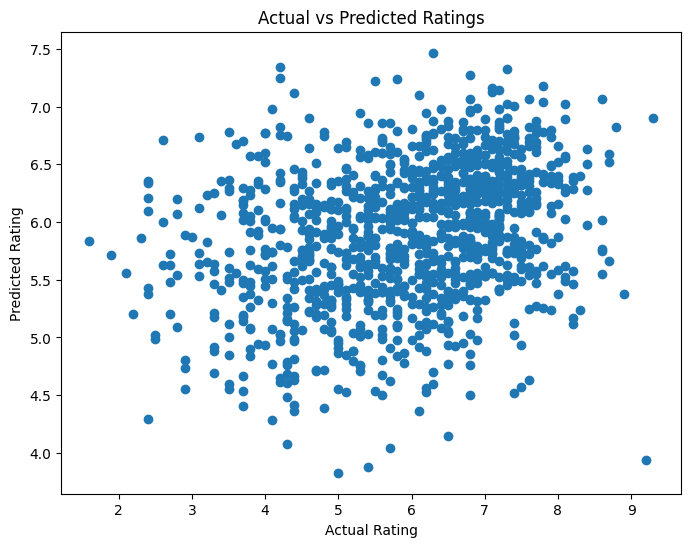

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Rating")

plt.ylabel("Predicted Rating")

plt.title("Actual vs Predicted Ratings")

plt.show()

In [20]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

    Feature  Importance
1  Director    0.203974
2   Actor 1    0.201177
0     Genre    0.199829
3   Actor 2    0.197705
4   Actor 3    0.197315


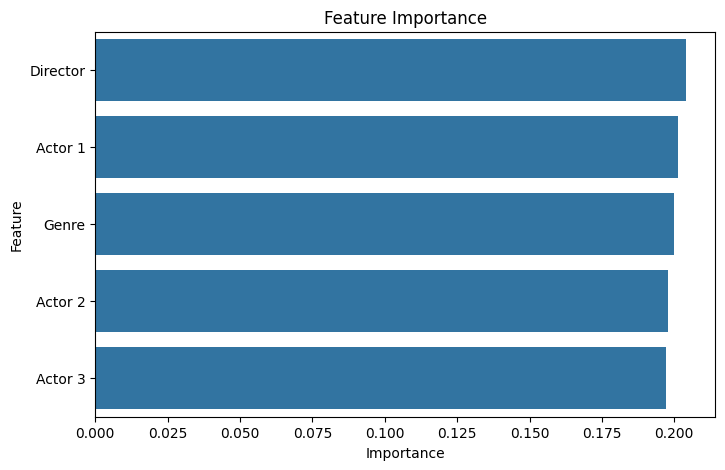

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

In [22]:
new_movie = pd.DataFrame({
    'Genre':[5],
    'Director':[20],
    'Actor 1':[50],
    'Actor 2':[30],
    'Actor 3':[10]
})

prediction = model.predict(new_movie)

print("Predicted Rating:", prediction[0])

Predicted Rating: 5.818500000000005


In [23]:
import joblib

joblib.dump(model, 'movie_rating_model.pkl')

['movie_rating_model.pkl']

In [24]:
from google.colab import files

files.download('movie_rating_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
df['Rating'].describe()

,Rating
count,5659.000000
mean,5.898533
std,1.381165
min,1.100000
25%,5.000000
50%,6.100000
75%,6.900000
max,10.000000


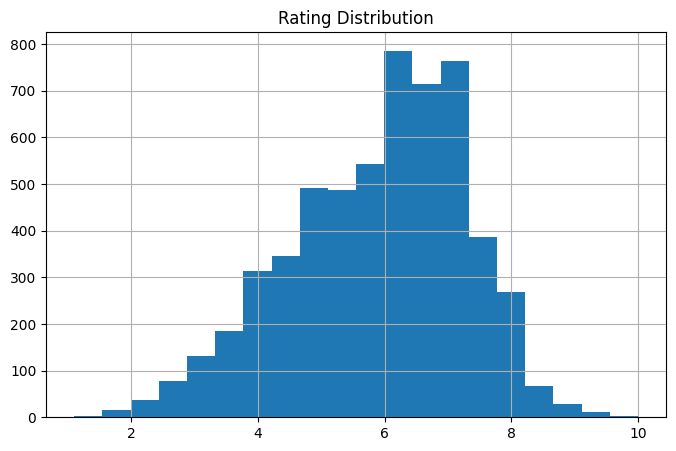

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df['Rating'].hist(bins=20)
plt.title("Rating Distribution")
plt.show()

In [27]:
df['Genre'].value_counts().head(20)

,count
Genre,
229,844
284,332
28,329
38,206
151,205
159,188
142,187
0,170
239,160


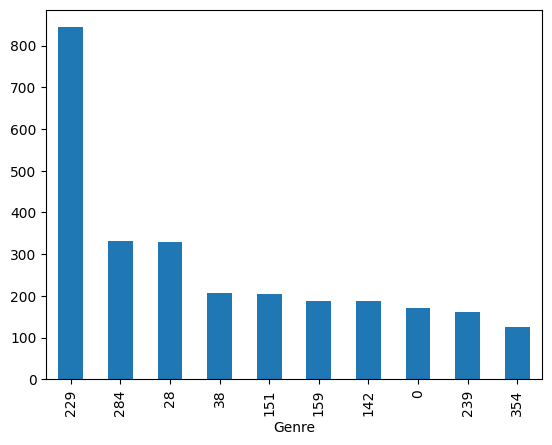

In [28]:
df['Genre'].value_counts().head(10).plot(kind='bar')
plt.show()

In [29]:
df['Director'].value_counts().head(10)

,count
Director,
480,41
1090,39
1975,33
1642,33
731,33
2348,30
1466,29
1651,23
370,23


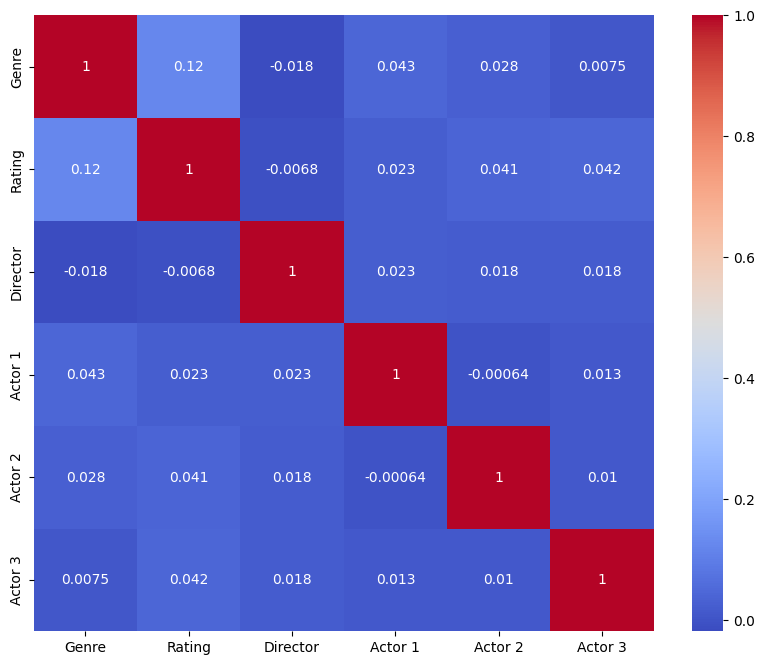

In [30]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.show()

In [31]:
df['Votes'] = df['Votes'].str.replace(',', '')
df['Votes'] = pd.to_numeric(df['Votes'])

In [32]:
df['Duration'] = df['Duration'].str.replace(' min', '')
df['Duration'] = pd.to_numeric(df['Duration'])

In [33]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['Genre','Director','Actor 1','Actor 2','Actor 3']:
    df[col] = le.fit_transform(df[col].astype(str))

In [34]:
X = df.drop('Rating', axis=1)

y = df['Rating']

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)